# `ui/main.py` — API Validation Walkthrough

Exercises the FastAPI backend using `TestClient`, which runs the app in-process
without needing to start a real server.  The same client is used by the unit tests;
here we focus on the full request/response flow with real data.

**Endpoints tested:**
- `POST /ask` — entry point; returns a plan or a disambiguation prompt
- `POST /plan` — used after disambiguation to scope the plan to a specific section
- `GET /images/{path}` — serves diagram images from `data/images/`

In [1]:
import sys, json, os
sys.path.insert(0, "..")
os.chdir("..")  # resolve data/chroma and data/images relative to project root

from dotenv import load_dotenv
load_dotenv(".env")

# TestClient runs the app in-process — no uvicorn needed
from fastapi.testclient import TestClient
from ui.main import app

client = TestClient(app)
print(f"Working directory: {os.getcwd()}")
print("TestClient ready")

Working directory: /home/raffled/moto-maintenance-local
TestClient ready


## 1. Unambiguous query → plan returned directly

A query that matches only one chapter goes straight through retrieval and planning
without a disambiguation step.  The response `type` is `"plan"`.

"Disassemble the fork cartridge" is cleanly contained in Ch. 6 — no cross-chapter
bleed — and also exercises the prerequisite walk (6.10 and 6.11 surface as depth-1
prerequisites of 6.12).

In [2]:
resp = client.post("/ask", json={"query": "disassemble the fork cartridge"})
print(f"Status: {resp.status_code}")

body = resp.json()
print(f"Type:          {body['type']}")
print(f"Sections used: {body['sections_used']}")
print(f"Torque specs:  {len(body['torque_specs'])}")
print(f"Image paths:   {len(body['image_paths'])}")
print()
print(body['text'])

Status: 200
Type:          plan
Sections used: ['6.11', '6.12', '6.10', '6.13', '6.14']
Torque specs:  0
Image paths:   38

# Fork Cartridge Disassembly Plan

---

## Section 6.10: Disassembling the Fork Legs

> **Note:** The operations are the same on both fork legs. The fork legs must already be removed before beginning.

1. Make a note of the current settings of rebound adjuster (1) and compression damping adjuster (2).
2. Open the adjusters of the rebound and compression damping completely.
3. Clamp the fork leg in the area of the lower triple clamp using the **Clamping Stand (T1403S)**.
4. Remove screw (3) and remove the compression damping adjuster.
5. Undo cartridge (4) using the **Ring Wrench (T14017)**.
   > **Note:** The cartridge cannot be removed yet at this stage.
6. Unclamp the fork leg and drain the fork oil into a suitable container.
7. Re-clamp the fork leg on the fork shoe using soft jaws.
8. Remove screw (5), remove the rebound damping adjuster, and remove rebound ad

## 2. Ambiguous query → disambiguation response

"Oil and filter change" matches sections in both Ch. 18 (engine-out assembly) and
Ch. 22 (routine maintenance).  The API returns a `"disambiguation"` response listing
the candidates grouped by chapter so the UI can present a picker.

In [3]:
resp = client.post("/ask", json={"query": "oil and filter change"})
print(f"Status: {resp.status_code}")

body = resp.json()
print(f"Type: {body['type']}")
print(f"Query echoed: {body['query']}")
print()
print("Candidates:")
for group in body['candidates']:
    print(f"  Ch. {group['chapter_num']} — {group['chapter_title']}")
    for sec in group['sections']:
        print(f"    {sec['section']}  {sec['section_title'] or '(no title)'}")

Status: 200
Type: disambiguation
Query echoed: oil and filter change

Candidates:
  Ch. 18 — engine
    18.3.3  Draining the engine oil and removing the oil filter
    18.5.9  Oil filter and oil screen, installing
  Ch. 22 — Lubrication system
    22.3  Changing the engine oil and oil filter, cleaning the oil screens
    22.5  Checking the oil pressure


## 3. POST /plan — scoped plan after disambiguation

The user selects Ch. 22.  The frontend calls `POST /plan` with the chosen section.
The response is a `"plan"` containing only Ch. 22 content — no engine-assembly
material from Ch. 18.

In [4]:
resp = client.post("/plan", json={"query": "change the engine oil and filter", "section": "22.3"})
print(f"Status: {resp.status_code}")

body = resp.json()
print(f"Type:          {body['type']}")
print(f"Sections used: {body['sections_used']}")

chapters_in_plan = sorted({int(s.split('.')[0]) for s in body['sections_used']})
print(f"Chapters:      {chapters_in_plan}  (Ch. 18 excluded)")
print()
print(body['text'])

Status: 200
Type:          plan
Sections used: ['8.4', '22.3']
Chapters:      [8, 22]  (Ch. 18 excluded)

# Engine Oil and Oil Filter Change – Repair Plan

---

## Safety Precautions (Read Before Starting)

1. Ensure the engine is at **operating temperature** before draining the oil — this ensures complete drainage.
2. **Wear suitable protective clothing and safety gloves** — engine oil will be hot and can cause scalding. If scalding occurs, rinse the affected area immediately with lukewarm water.
3. Ensure **adequate ventilation** in the work area before running the engine at any point.
4. Dispose of all used oil, filters, and sealing components correctly and in accordance with applicable environmental regulations.

---

## Preparatory Work

1. Remove the **skid plate** (refer to p. 57).
2. Park the motorcycle on a **level surface**.

---

## Main Work

### Drain the Engine Oil

1. Position an **appropriate container** beneath the engine to catch the draining oil.
2. Remove **oil drai

## 4. POST /plan — 404 for unknown section

In [5]:
resp = client.post("/plan", json={"query": "test", "section": "99.99"})
print(f"Status: {resp.status_code}")
print(f"Detail: {resp.json()['detail']}")

Status: 404
Detail: Section '99.99' not found


## 5. GET /images — serve a diagram file

Image paths come back in every `PlanResponse`.  The frontend uses them to render
diagrams inline.  Here we call `POST /plan` for section 7.2 (handlebar adjustment —
known to have diagrams) and then fetch the first image via `GET /images`.

Status: 200  |  3 image(s) returned

GET /images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0050_00.jpg
  Status: 200  Content-Type: image/jpeg  Size: 30,195 bytes


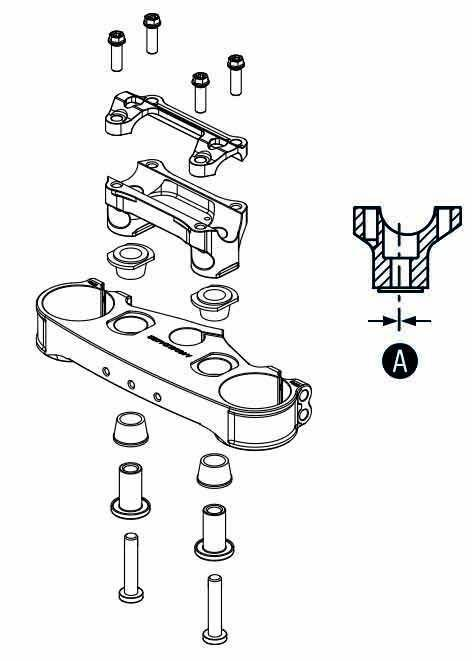


GET /images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0050_01.jpg
  Status: 200  Content-Type: image/jpeg  Size: 30,220 bytes


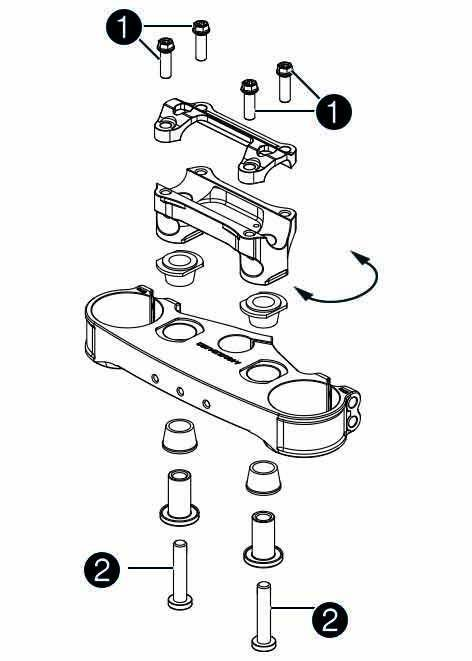


GET /images/FE_501s_2026_US_en_Bundle_RM_069969-000001_05sq_m1du/p0051_00.jpg
  Status: 200  Content-Type: image/jpeg  Size: 11,657 bytes


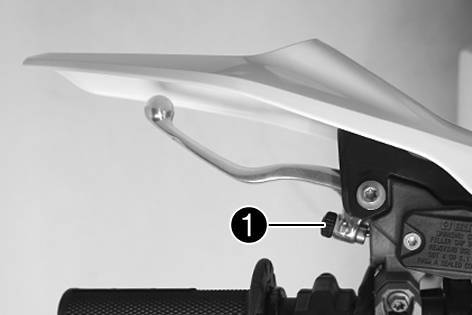

In [6]:
from pathlib import Path
from IPython.display import display, Image as IPImage

# Use POST /plan for a specific section to get a guaranteed plan response with images
resp = client.post("/plan", json={"query": "adjust the handlebar position", "section": "7.2"})
image_paths = resp.json().get("image_paths", [])

print(f"Status: {resp.status_code}  |  {len(image_paths)} image(s) returned")
print()

if image_paths:
    for path in image_paths:
        relative = str(Path(path).relative_to("data/images"))
        img_resp = client.get(f"/images/{relative}")
        print(f"GET /images/{relative}")
        print(f"  Status: {img_resp.status_code}  Content-Type: {img_resp.headers.get('content-type')}  Size: {len(img_resp.content):,} bytes")
        display(IPImage(data=img_resp.content, width=400))
        print()
else:
    print("No images in this result set.")

In [7]:
# 404 for a missing path
resp = client.get("/images/nonexistent/file.jpg")
print(f"Status: {resp.status_code}")
print(f"Detail: {resp.json()['detail']}")

Status: 404
Detail: Image not found


## 6. Response schema reference

FastAPI auto-generates an OpenAPI schema.  The full interactive docs are available
at `http://localhost:8000/docs` when the server is running.

Here we print the schema for both response types directly from the app.

In [8]:
resp = client.get("/openapi.json")
schema = resp.json()

for name in ["PlanResponse", "DisambiguationResponse"]:
    defn = schema["components"]["schemas"][name]
    print(f"\n{name}:")
    for field, props in defn.get("properties", {}).items():
        typ = props.get("type") or props.get("$ref", "").split("/")[-1]
        print(f"  {field:<20} {typ}")


PlanResponse:
  type                 string
  query                string
  sections_used        array
  text                 string
  torque_specs         array
  image_paths          array

DisambiguationResponse:
  type                 string
  query                string
  candidates           array
